In [291]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [292]:
icici=pd.read_csv(r"IPEG Historical Data.csv")
kotak=pd.read_csv(r"KTGF Historical Data.csv")
sbi=pd.read_csv(r"SBIG Historical Data.csv")
hdfc=pd.read_csv(r"HDGO Historical Data.csv")
nippon=pd.read_csv(r"GBES Historical Data.csv")

In [293]:
gold=pd.read_csv(r"Gold Futures Historical Data.csv")

In [294]:
sensex=pd.read_csv(r"BSE Sensex 30 Historical Data.csv")

# Data Cleaning

In [295]:
icici.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      495 non-null    object 
 1   Price     495 non-null    float64
 2   Open      495 non-null    float64
 3   High      495 non-null    float64
 4   Low       495 non-null    float64
 5   Vol.      495 non-null    object 
 6   Change %  495 non-null    object 
dtypes: float64(4), object(3)
memory usage: 27.2+ KB


In [296]:
icici.describe()

,Price,Open,High,Low
count,495.000000,495.000000,495.000000,495.000000
mean,83.919051,84.588970,85.193737,82.997879
std,22.708906,22.622994,23.113696,22.146335
min,59.680000,59.500000,60.250000,59.000000
25%,64.960000,65.615000,65.875000,64.515000
50%,76.510000,77.250000,77.590000,76.200000
75%,98.965000,98.670000,100.720000,96.585000
max,153.330000,147.390000,158.000000,147.360000


In [297]:
icici.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,30-03-2026,125.34,124.47,125.84,121.45,14.56M,3.21%
1,27-03-2026,121.44,121.35,122.76,119.65,16.04M,-1.66%
2,25-03-2026,123.49,122.55,124.98,122.55,11.58M,3.28%
3,24-03-2026,119.57,115.18,120.33,115.02,22.62M,5.36%
4,23-03-2026,113.49,120.66,120.66,110.64,37.14M,-9.34%


In [298]:
icici=icici[::-1]
kotak=kotak[::-1]
sbi=sbi[::-1]
hdfc=hdfc[::-1]
nippon=nippon[::-1]

In [299]:
icici.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 494 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      495 non-null    object 
 1   Price     495 non-null    float64
 2   Open      495 non-null    float64
 3   High      495 non-null    float64
 4   Low       495 non-null    float64
 5   Vol.      495 non-null    object 
 6   Change %  495 non-null    object 
dtypes: float64(4), object(3)
memory usage: 27.2+ KB


In [300]:
icici.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')

In [301]:
icici.shape[0]==icici["Date"].nunique()   #every row is a unique day

True

In [302]:
icici["Date"]=pd.to_datetime(icici["Date"],format="%d-%m-%Y")
sbi["Date"]=pd.to_datetime(sbi["Date"],format="%d-%m-%Y")
nippon["Date"]=pd.to_datetime(nippon["Date"],format="%d-%m-%Y")
kotak["Date"]=pd.to_datetime(kotak["Date"],format="%d-%m-%Y")
hdfc["Date"]=pd.to_datetime(hdfc["Date"],format="%d-%m-%Y")     #convertiong string to datetime

Merging data

In [303]:
icici.reset_index(drop=True,inplace=True)
kotak.reset_index(drop=True,inplace=True)
sbi.reset_index(drop=True,inplace=True)
nippon.reset_index(drop=True,inplace=True)
hdfc.reset_index(drop=True,inplace=True)

In [304]:
icici.shape[0]==sbi.shape[0]==kotak.shape[0]  #Numbers of column varies

False

In [305]:
icici.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')

In [306]:
df=icici[["Date","Price"]].rename(columns={"Price":"icici"})

In [307]:
df=df.merge(kotak[["Date","Price"]].rename(columns={"Price":"kotak"}),on="Date",how="inner")

In [308]:
df=df.merge(sbi[["Date","Price"]].rename(columns={"Price":"sbi"}),on="Date",how="inner")

In [309]:
df=df.merge(nippon[["Date","Price"]].rename(columns={"Price":"nippon"}),on="Date",how="inner")

In [310]:
df=df.merge(hdfc[["Date","Price"]].rename(columns={"Price":"hdfc"}),on="Date",how="inner")

In [311]:
df.head() #final df

,Date,icici,kotak,sbi,nippon,hdfc
0,2024-04-15,63.02,61.57,63.41,61.23,63.12
1,2024-04-16,63.62,62.16,63.69,61.89,63.75
2,2024-04-18,63.76,62.16,63.89,61.96,63.87
3,2024-04-19,63.97,62.55,64.21,62.24,64.11
4,2024-04-22,63.53,62.06,63.46,61.74,63.71


# Is any ETF better than the others?

In [312]:
per_change_df=df.copy()

In [313]:
per_change_df.iloc[:,1:]=per_change_df.iloc[:,1:].pct_change()

In [314]:
per_change_df.corr(numeric_only=True) #they are strongly correlated to each other

,icici,kotak,sbi,nippon,hdfc
icici,1.000000,0.977341,0.979289,0.979768,0.980042
kotak,0.977341,1.000000,0.978281,0.983323,0.977890
sbi,0.979289,0.978281,1.000000,0.985990,0.982711
nippon,0.979768,0.983323,0.985990,1.000000,0.985131
hdfc,0.980042,0.977890,0.982711,0.985131,1.000000


<Axes: >

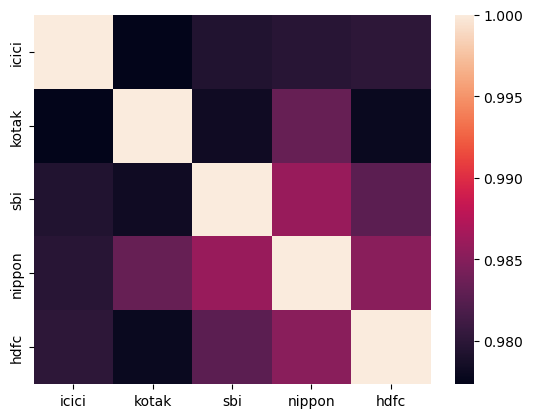

In [315]:
sns.heatmap(per_change_df.corr(numeric_only=True))

In [316]:
#The ETFs are similar to each other

# **Do ETFs move in the same way as gold?**

In [317]:
gold.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,01-04-2024,"2,245.90","2,243.50","2,275.00","2,238.50",277.23K,2.02%
1,02-04-2024,"2,270.30","2,260.20","2,290.10","2,256.10",254.57K,1.09%
2,03-04-2024,"2,303.30","2,290.00","2,310.00","2,275.10",236.23K,1.45%
3,04-04-2024,"2,296.90","2,308.90","2,312.00","2,288.40",293.21K,-0.28%
4,08-04-2024,"2,339.00","2,332.20","2,357.00","2,310.50",279.61K,1.83%


In [318]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      417 non-null    object
 1   Price     417 non-null    object
 2   Open      417 non-null    object
 3   High      417 non-null    object
 4   Low       417 non-null    object
 5   Vol.      415 non-null    object
 6   Change %  417 non-null    object
dtypes: object(7)
memory usage: 22.9+ KB


In [319]:
gold["Price"]=gold["Price"].str.replace(",","").astype("float") #converting string to float

In [320]:
gold["Date"]=pd.to_datetime(gold["Date"],format="%d-%m-%Y") #converting string to datetime

In [321]:
inr=pd.read_csv(r"USD_INR Historical Data.csv")  #importing actual prices of gold

In [322]:
inr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      522 non-null    object 
 1   Price     522 non-null    float64
 2   Open      522 non-null    float64
 3   High      522 non-null    float64
 4   Low       522 non-null    float64
 5   Vol.      0 non-null      float64
 6   Change %  522 non-null    object 
dtypes: float64(5), object(2)
memory usage: 28.7+ KB


In [323]:
inr["Date"]=pd.to_datetime(inr["Date"],format="%d-%m-%Y")  #converting string to datetikme

In [324]:
gold=gold.merge(inr[["Date","Price"]].rename(columns={"Price":"inr"}),how="inner",on="Date")

In [325]:
gold["Price"]=gold["Price"]*gold["inr"]  #Converting dollar to inr

In [326]:
gold.head()

,Date,Price,Open,High,Low,Vol.,Change %,inr
0,2024-04-01,187281.1092,"2,243.50","2,275.00","2,238.50",277.23K,2.02%,83.388
1,2024-04-02,189229.5050,"2,260.20","2,290.10","2,256.10",254.57K,1.09%,83.350
2,2024-04-03,192350.8863,"2,290.00","2,310.00","2,275.10",236.23K,1.45%,83.511
3,2024-04-04,191481.0685,"2,308.90","2,312.00","2,288.40",293.21K,-0.28%,83.365
4,2024-04-08,194803.6150,"2,332.20","2,357.00","2,310.50",279.61K,1.83%,83.285


In [327]:
df=df.merge(gold[["Date","Price"]].rename(columns={"Price":"gold"}),on="Date",how="inner")

In [328]:
per_change_df=df.copy()

In [329]:
per_change_df.iloc[:,1:]=per_change_df.iloc[:,1:].pct_change()
per_change_df.head()

,Date,icici,kotak,sbi,nippon,hdfc,gold
0,2024-04-15,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-04-16,0.009521,0.009583,0.004416,0.010779,0.009981,0.012227
2,2024-04-18,0.002201,0.000000,0.003140,0.001131,0.001882,-0.005537
3,2024-04-22,-0.003607,-0.001609,-0.006730,-0.003551,-0.002505,-0.023452
4,2024-04-23,-0.021879,-0.022720,-0.017964,-0.024133,-0.019777,-0.002887


In [330]:
per_change_df.corr(numeric_only=True)

,icici,kotak,sbi,nippon,hdfc,gold
icici,1.000000,0.979136,0.982233,0.985697,0.983005,0.579167
kotak,0.979136,1.000000,0.979679,0.987598,0.978950,0.623035
sbi,0.982233,0.979679,1.000000,0.989750,0.986709,0.584377
nippon,0.985697,0.987598,0.989750,1.000000,0.989700,0.599855
hdfc,0.983005,0.978950,0.986709,0.989700,1.000000,0.581111
gold,0.579167,0.623035,0.584377,0.599855,0.581111,1.000000


In [331]:
#Gold and gold ETFs show a moderate positive correlation, with correlations ranging from approximately 0.58 to 0.62

Gold prices are based on the U.S. market, while the ETFs and Sensex are Indian-market instruments. 
Differences in trading hours, market holidays, and currency effects may affect the measured correlation

# **Identifying the relation between sensex and gold**

In [332]:
sensex.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,30-03-2026,"71,947.55","72,565.22","73,165.32","71,774.13",26.57M,-2.22%
1,27-03-2026,"73,583.22","74,883.79","74,904.91","73,534.41",28.82M,-2.25%
2,25-03-2026,"75,273.45","74,652.01","75,849.76","74,550.47",31.00M,1.63%
3,24-03-2026,"74,068.45","74,212.47","74,489.39","73,084.46",20.66M,1.89%
4,23-03-2026,"72,696.39","73,732.58","73,732.58","72,558.44",19.28M,-2.46%


In [333]:
sensex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      496 non-null    object
 1   Price     496 non-null    object
 2   Open      496 non-null    object
 3   High      496 non-null    object
 4   Low       496 non-null    object
 5   Vol.      496 non-null    object
 6   Change %  496 non-null    object
dtypes: object(7)
memory usage: 27.2+ KB


In [334]:
sensex["Price"]=sensex["Price"].str.replace(",","").astype("float") #converting string to float
sensex["Date"]=pd.to_datetime(sensex["Date"],format="%d-%m-%Y") #converting string to datetime

In [335]:
temp2=gold[["Date","Price"]].merge(sensex[["Date","Price"]],how="inner",on="Date",suffixes=("_gold","_sensex"))

In [336]:
temp2.columns

Index(['Date', 'Price_gold', 'Price_sensex'], dtype='object')

In [337]:
temp2.iloc[:,1:]=temp2.iloc[:,1:].pct_change()

In [338]:
temp2.corr(numeric_only=True)

,Price_gold,Price_sensex
Price_gold,1.000000,0.159721
Price_sensex,0.159721,1.000000


In [339]:
#Gold and sensex show a low positive correlation 

# **Fluctuation between each ETF and gold**

In [340]:
per_change_df.head()

,Date,icici,kotak,sbi,nippon,hdfc,gold
0,2024-04-15,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-04-16,0.009521,0.009583,0.004416,0.010779,0.009981,0.012227
2,2024-04-18,0.002201,0.000000,0.003140,0.001131,0.001882,-0.005537
3,2024-04-22,-0.003607,-0.001609,-0.006730,-0.003551,-0.002505,-0.023452
4,2024-04-23,-0.021879,-0.022720,-0.017964,-0.024133,-0.019777,-0.002887


In [341]:
per_change_df.iloc[:,1:]=per_change_df.iloc[:,1:]*100

In [342]:
per_change_df.head()

,Date,icici,kotak,sbi,nippon,hdfc,gold
0,2024-04-15,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-04-16,0.952079,0.958259,0.441571,1.077903,0.998099,1.222689
2,2024-04-18,0.220057,0.000000,0.314021,0.113104,0.188235,-0.553726
3,2024-04-22,-0.360728,-0.160875,-0.673032,-0.355068,-0.250509,-2.345159
4,2024-04-23,-2.187943,-2.271995,-1.796407,-2.413346,-1.977712,-0.288704


In [343]:
print("nippon standard deviation :- ",round(per_change_df["nippon"].std(),ndigits=5))
print("icici standard deviation :-  ",round(per_change_df["icici"].std(),ndigits=5))
print("hdfc standard deviation :-   ",round(per_change_df["hdfc"].std(),ndigits=5))
print("sbi standard deviation :-    ",round(per_change_df["sbi"].std(),ndigits=5))
print("kotak standard deviation :-  ",round(per_change_df["kotak"].std(),ndigits=5))

nippon standard deviation :-  1.71962
icici standard deviation :-   1.72221
hdfc standard deviation :-    1.73045
sbi standard deviation :-     1.67068
kotak standard deviation :-   1.69139


In [344]:
#hdfc is the most volatile ,whereas sbi is the most stable

In [345]:
import matplotlib.dates as mdates

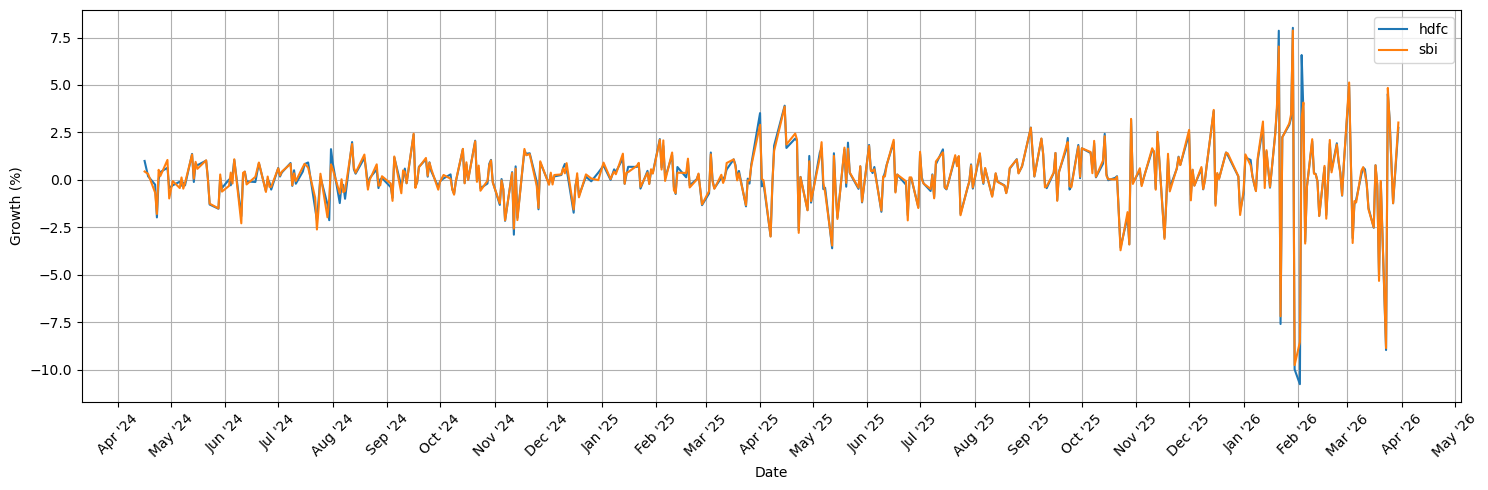

In [346]:
plot_df = per_change_df.set_index("Date")

plt.figure(figsize=(15,5))
sns.lineplot(data=plot_df["hdfc"], label="hdfc")
sns.lineplot(data=plot_df["sbi"], label="sbi")
# sns.lineplot(data=plot_df["gold"], label="gold")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.xticks(rotation=45)
plt.xlabel("Date"); plt.ylabel("Growth (%)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

In [347]:
per_change_df.groupby(per_change_df["Date"].dt.year)[["hdfc", "sbi","gold"]].std()

,hdfc,sbi,gold
Date,,,
2024,0.906442,0.905071,1.112786
2025,1.234559,1.242720,1.409497
2026,3.565986,3.364673,2.557824


In [348]:
# 2024: nearly identical
# 2025: SBI marginally more volatile
# 2026: HDFC clearly more volatile wheras gold shows some stability

Sharpe ratio

In [349]:
returns = per_change_df.set_index("Date") / 100

In [350]:
# Risk-free rate
risk_free_rate = 0.06
annualized_return = returns.mean() * 252
annualized_volatility = returns.std() * np.sqrt(252)

# Calculate Sharpe Ratio
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

In [351]:
sharpe_df = pd.DataFrame({
    "Annualized Return": annualized_return,
    "Annualized Volatility": annualized_volatility,
    "Sharpe Ratio": sharpe_ratio
})

sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio", ascending=False
)

sharpe_df.round(3)

,Annualized Return,Annualized Volatility,Sharpe Ratio
gold,0.545,0.247,1.962
sbi,0.485,0.265,1.603
kotak,0.490,0.268,1.600
icici,0.493,0.273,1.584
nippon,0.490,0.273,1.574
hdfc,0.489,0.275,1.563


In [397]:
#Gold had the highest annualized average daily return amoungs all

 # **Comparision and visualization**

In [353]:
df_=df.merge(sensex[["Date","Price"]].rename(columns={"Price":"sensex"}),how="inner",on="Date")

In [354]:
df_.head()

,Date,icici,kotak,sbi,nippon,hdfc,gold,sensex
0,2024-04-15,63.02,61.57,63.41,61.23,63.12,197998.6008,73399.78
1,2024-04-16,63.62,62.16,63.69,61.89,63.75,200419.5075,72943.68
2,2024-04-18,63.76,62.16,63.89,61.96,63.87,199309.7320,72488.99
3,2024-04-22,63.53,62.06,63.46,61.74,63.71,194635.6020,73648.62
4,2024-04-23,62.14,60.65,62.32,60.25,62.45,194073.6803,73738.45


In [355]:
standard_df=df_.copy()
for i in df_.columns[1:]:
    standard_df[i]=(standard_df[i]/df_[i][0])*100

In [356]:
standard_df["icici"][0]

100.0

In [357]:
standard_df

,Date,icici,kotak,sbi,nippon,hdfc,gold,sensex
0,2024-04-15,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,2024-04-16,100.952079,100.958259,100.441571,101.077903,100.998099,101.222689,99.378608
2,2024-04-18,101.174230,100.958259,100.756978,101.192226,101.188213,100.662192,98.759138
3,2024-04-22,100.809267,100.795842,100.078852,100.832925,100.934728,98.301504,100.339020
4,2024-04-23,98.603618,98.505766,98.281028,98.399477,98.938530,98.017703,100.461405
...,...,...,...,...,...,...,...,...
377,2026-03-23,180.085687,180.656164,179.340798,180.826392,180.465779,208.250261,99.041700
378,2026-03-24,189.733418,188.923177,188.030279,188.616691,188.640684,209.840864,100.910997
379,2026-03-25,195.953666,194.932597,193.881091,194.822799,194.787706,216.677769,102.552692
380,2026-03-27,192.700730,192.333929,191.483993,191.948391,192.395437,215.826841,100.249919


In [358]:
# df_2024 = standard_df[standard_df["Date"].dt.year == 2024]

# plt.figure(figsize=(15, 5))

# # melt to long-form so each column becomes a "variable" series, with Date as x
# df_melted = df_2024.melt(id_vars="Date", var_name="Series", value_name="Growth")

# sns.lineplot(data=df_melted, x="Date", y="Growth", hue="Series")

# plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
# plt.xlabel("Date")
# plt.ylabel("Growth")
# plt.legend()
# plt.grid(True)
# plt.show()

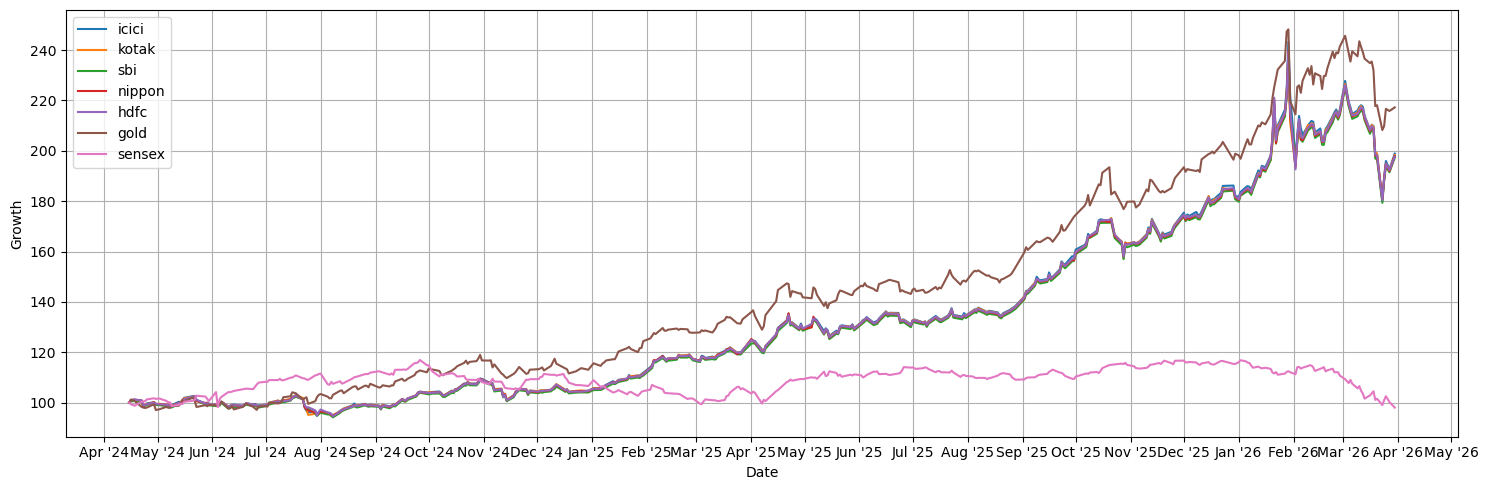

In [359]:
plt.figure(figsize=(15, 5))

# melt to long-form so each column becomes a "variable" series, with Date as x
df_melted_ = standard_df.melt(id_vars="Date", var_name="Series", value_name="Growth")

sns.lineplot(data=df_melted_, x="Date", y="Growth", hue="Series")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [360]:
per_change_df_=df_.iloc[:,1:7].pct_change()

<Axes: >

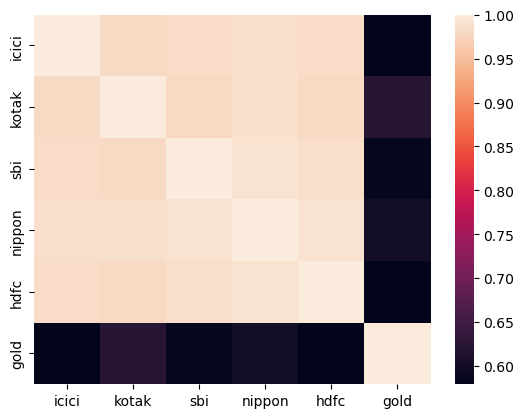

In [361]:
sns.heatmap(per_change_df_.corr())

**Year on year growth**

In [362]:
df_["Year"]=df_["Date"].dt.year

In [363]:
df_["Month"]=df_["Date"].dt.strftime("%b")

In [364]:
growth_YOY=df_.groupby('Year')[['icici', 'kotak', 'sbi', 'nippon', 'hdfc', 'gold', 'sensex']].last()

In [365]:
growth_YOY.pct_change()

,icici,kotak,sbi,nippon,hdfc,gold,sensex
Year,,,,,,,
2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025,0.740527,0.733116,0.737760,0.737031,0.738617,0.759005,0.082136
2026,0.091432,0.093613,0.091155,0.090132,0.085523,0.092377,-0.150310


**Performance**

In [366]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

df_["Month"] = pd.Categorical(
    df_["Month"],
    categories=month_order,
    ordered=True
)

In [367]:
growth_MoM=df_.groupby(['Year','Month'],observed=True)[['icici', 'kotak', 'sbi', 'nippon', 'hdfc', 'gold', 'sensex']].last()

In [368]:
per_growth_MoM=growth_MoM.pct_change()

In [369]:
per_growth_MoM

icici     kotak       sbi    nippon      hdfc      gold  \
Year Month                                                               
2024 Apr         NaN       NaN       NaN       NaN       NaN       NaN   
     May    0.000638 -0.001306 -0.001273 -0.002300 -0.003182  0.020594   
     Jun   -0.006853 -0.007521 -0.009245 -0.006915 -0.007501 -0.006007   
     Jul   -0.028402 -0.028830 -0.026223 -0.027188 -0.021547  0.046887   
     Aug    0.033031  0.035793  0.032215  0.032209  0.026623  0.042532   
     Sep    0.048761  0.047494  0.049456  0.049199  0.049624  0.042505   
     Oct    0.051067  0.051438  0.050328  0.053029  0.050785  0.042087   
     Nov   -0.042350 -0.040892 -0.042108 -0.044232 -0.041800 -0.031484   
     Dec   -0.000757 -0.001395  0.000000  0.000625  0.001363 -0.000243   
2025 Jan    0.068354  0.065828  0.064272  0.063906  0.062169  0.100342   
     Feb    0.047524  0.052731  0.054693  0.055662  0.054543  0.026849   
     Mar    0.031419  0.026705  0.027414  0.026711  0.028494  0.041571   
     Apr    0.071297  0.071159  0.071372  0.071680  0.072610  0.065860   
     May    0.000981  0.002391  0.000859  0.000126 -0.001102  0.017237   
     Jun    0.011510  0.010543  0.010174  0.011252  0.011397 -0.007572   
     Jul    0.027236  0.028071  0.027788  0.027628  0.027384  0.033912   
     Aug    0.027811  0.027184  0.027037  0.027007  0.027126  0.038332   
     Sep    0.141596  0.131498  0.139671  0.135394  0.139511  0.130724   
     Oct    0.032038  0.044491  0.034295  0.039958  0.035167  0.034404   
     Nov    0.047879  0.046676  0.048176  0.045144  0.047893  0.052661   
     Dec    0.066493  0.061424  0.066617  0.067095  0.067719  0.050915   
2026 Jan    0.215778  0.165905  0.189812  0.179455  0.185488  0.104986   
     Feb   -0.023850  0.020284 -0.004399  0.003661 -0.001688  0.098508   
     Mar   -0.080343 -0.080654 -0.078866 -0.079103 -0.082776 -0.100062   

              sensex  
Year Month            
2024 Apr         NaN  
     May   -0.008018  
     Jun    0.072512  
     Jul    0.031525  
     Aug    0.004811  
     Sep    0.026361  
     Oct   -0.058253  
     Nov    0.010644  
     Dec   -0.024752  
2025 Jan   -0.019021  
     Feb   -0.027975  
     Mar    0.040127  
     Apr    0.033964  
     May    0.017332  
     Jun    0.024175  
     Jul   -0.028956  
     Aug   -0.013611  
     Sep    0.002336  
     Oct    0.051538  
     Nov    0.014277  
     Dec   -0.010915  
2026 Jan   -0.028406  
     Feb   -0.011944  
     Mar   -0.114897

In [370]:
per_growth_MoM.describe()

,icici,kotak,sbi,nippon,hdfc,gold,sensex
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,0.032211,0.031696,0.031829,0.031739,0.031665,0.036763,-0.000745
std,0.060635,0.052153,0.056226,0.054542,0.055739,0.048691,0.039366
min,-0.080343,-0.080654,-0.078866,-0.079103,-0.082776,-0.100062,-0.114897
25%,-0.000060,0.000542,-0.000637,0.000376,-0.001395,0.018916,-0.021886
50%,0.031419,0.028071,0.027788,0.027628,0.027384,0.041571,0.002336
75%,0.049914,0.052085,0.052510,0.054345,0.052664,0.051788,0.025268
max,0.215778,0.165905,0.189812,0.179455,0.185488,0.130724,0.072512


In [371]:
#average monthly growth of the ETFs is approximately 4.3%, while gold averages approximately 4.8%

In [372]:
gold_2024_min=per_growth_MoM.loc[2024][per_growth_MoM.loc[2024,"gold"]==per_growth_MoM.loc[2024,"gold"].min()]
gold_2024_max=per_growth_MoM.loc[2024][per_growth_MoM.loc[2024,"gold"]==per_growth_MoM.loc[2024,"gold"].max()]

In [373]:
return_2024=pd.concat([gold_2024_max,gold_2024_min])
return_2024

,icici,kotak,sbi,nippon,hdfc,gold,sensex
Month,,,,,,,
Jul,-0.028402,-0.028830,-0.026223,-0.027188,-0.021547,0.046887,0.031525
Nov,-0.042350,-0.040892,-0.042108,-0.044232,-0.041800,-0.031484,0.010644


In [374]:
return_2024.loc["Jul"].iloc[:5].sort_values() #SBI reacted the least and Kotak reacted the most in 2024 when gold was high

kotak    -0.028830
icici    -0.028402
nippon   -0.027188
sbi      -0.026223
hdfc     -0.021547
Name: Jul, dtype: float64

In [375]:
return_2024.loc["Nov"].iloc[:5].sort_values() #HDFC reacted the least and Kotak reacted the most in 2024 when gold was high

nippon   -0.044232
icici    -0.042350
sbi      -0.042108
hdfc     -0.041800
kotak    -0.040892
Name: Nov, dtype: float64

In [376]:
gold_2025_min=per_growth_MoM.loc[2025][per_growth_MoM.loc[2025,"gold"]==per_growth_MoM.loc[2025,"gold"].min()]
gold_2025_max=per_growth_MoM.loc[2025][per_growth_MoM.loc[2025,"gold"]==per_growth_MoM.loc[2025,"gold"].max()]

In [377]:
return_2025=pd.concat([gold_2025_max,gold_2025_min])
return_2025

,icici,kotak,sbi,nippon,hdfc,gold,sensex
Month,,,,,,,
Sep,0.141596,0.131498,0.139671,0.135394,0.139511,0.130724,0.002336
Jun,0.011510,0.010543,0.010174,0.011252,0.011397,-0.007572,0.024175


In [378]:
 return_2025.loc["Sep"].iloc[:5].sort_values() #Nipon reacted the least and Kotak reacted the most in 2025 when gold was high

kotak     0.131498
nippon    0.135394
hdfc      0.139511
sbi       0.139671
icici     0.141596
Name: Sep, dtype: float64

In [379]:
return_2025.loc["Jun"].iloc[:5].sort_values() #Kotak reacted the least and ICICI reacted the most in 2025 when gold was high

sbi       0.010174
kotak     0.010543
nippon    0.011252
hdfc      0.011397
icici     0.011510
Name: Jun, dtype: float64

In [380]:
gold_2026_min=per_growth_MoM.loc[2026][per_growth_MoM.loc[2026,"gold"]==per_growth_MoM.loc[2026,"gold"].min()]
gold_2026_max=per_growth_MoM.loc[2026][per_growth_MoM.loc[2026,"gold"]==per_growth_MoM.loc[2026,"gold"].max()]

In [381]:
return_2026=pd.concat([gold_2026_max,gold_2026_min])
return_2026

,icici,kotak,sbi,nippon,hdfc,gold,sensex
Month,,,,,,,
Jan,0.215778,0.165905,0.189812,0.179455,0.185488,0.104986,-0.028406
Mar,-0.080343,-0.080654,-0.078866,-0.079103,-0.082776,-0.100062,-0.114897


In [382]:
return_2026.loc["Jan"].iloc[:5].sort_values() #ICICI reacted the least and Kotak reacted the most in 2026 when gold was high

kotak     0.165905
nippon    0.179455
hdfc      0.185488
sbi       0.189812
icici     0.215778
Name: Jan, dtype: float64

In [383]:
return_2026.loc["Mar"].iloc[:5].sort_values() #ICICI reacted the least and Kotak reacted the most in 2026 when gold was high

hdfc     -0.082776
kotak    -0.080654
icici    -0.080343
nippon   -0.079103
sbi      -0.078866
Name: Mar, dtype: float64

In [384]:
#fluction of gold was very high from jan 2026 to march 2026

In [385]:
df_2026=df_[df_["Year"]==2026]

In [386]:
df_2026[["gold","sensex"]].pct_change().corr()

,gold,sensex
gold,1.000000,0.380039
sensex,0.380039,1.000000


In [391]:
per_growth_MoM.loc[2026,["gold","sensex"]]*100

,gold,sensex
Month,,
Jan,10.498589,-2.840623
Feb,9.850797,-1.194351
Mar,-10.006208,-11.489682


In [396]:
#Gold and the Sensex behaved very differently during the first three months of 2026. 
# Gold shows approx 10% growth in first 2 months whereas sensex trends to decline 
#Both gold and sensex shows -10% and -11.5% decline during the anoouncement of budget

In [388]:
per_growth_MoM.corr()

,icici,kotak,sbi,nippon,hdfc,gold,sensex
icici,1.000000,0.976954,0.995094,0.989725,0.992554,0.744636,0.051404
kotak,0.976954,1.000000,0.991792,0.996301,0.992420,0.831012,0.086552
sbi,0.995094,0.991792,1.000000,0.998573,0.999186,0.784181,0.056968
nippon,0.989725,0.996301,0.998573,1.000000,0.998651,0.797242,0.066815
hdfc,0.992554,0.992420,0.999186,0.998651,1.000000,0.794367,0.076330
gold,0.744636,0.831012,0.784181,0.797242,0.794367,1.000000,0.225805
sensex,0.051404,0.086552,0.056968,0.066815,0.076330,0.225805,1.000000


# **Final Insights**